# S21 simulation and fitting of a resonator

Authors: Samarth Hawaldar, Arvind Mamgain

Adapted from tutorial 4.16


In [62]:
# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

In [63]:
import numpy as np

# Set up the design

In [64]:
# Set up chip dimensions 
design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
design._chips['main']['size']['size_z'] = '-525um'
# Resonator and feedline gap width (W) and center conductor width (S) from reference 2
design.variables['cpw_width'] = '10 um' #S from reference 2
design.variables['cpw_gap'] = '6 um' #W from reference 2


design.overwrite_enabled = True

hfss = design.renderers.hfss

# Open GUI
gui = MetalGUI(design)

In [4]:
# Define for renderer
eig_qres = EPRanalysis(design, "hfss")
#hfss = design.renderers.hfss
hfss = eig_qres.sim.renderer
q3d = design.renderers.q3d

# Define the geometry

Here we will have a single feedline couple to a single CPW resonator.

The lauchpad should be included in the driven model simulations.

For that reason, we use the LaunchpadWirebondDriven component which has an extra pin for input/output

In [65]:
###################
# Single feedline #
###################

# Driven Lauchpad 1
x = '-0.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)

# Driven Launchpad 2
x = '0.5mm'
y = '2.0mm'
launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='180', lead_length='30um')
LP2 = LaunchpadWirebondDriven(design, 'LP2', options = launch_options)

# coupling resonator to feedline 
q_read = CoupledLineTee(design,'Q_Read_T', options=dict(pos_x = '0.0mm', pos_y = '2mm', 
                                                        orientation = '0',
                                                        coupling_space = '6um',                                                         
                                                        coupling_length = '300um',
                                                        open_termination = False))


gui.rebuild()


In [66]:

# Using path finder to connect the two launchpads
TL_LP1_T = RoutePathfinder(design, 'TL_LP1_T', options = dict(chip='main', trace_width ='10um',
        trace_gap ='6um',
                                            fillet='99um',
                                                                  
        hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='Q_Read_T',
                                                    pin='prime_start')
                                            )))

TL_T_LP2 = RoutePathfinder(design, 'TL_T_LP2', options = dict(chip='main', trace_width ='10um',
        trace_gap ='6um',
                                            fillet='99um',
                                                                  
        hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='Q_Read_T',
                                                    pin='prime_end'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))
# # Rebuild the GUI

In [67]:
######################
# lambda/4 resonator #
######################

# First we define the two end-points
otg = OpenToGround(design, 'otg', options=dict(chip='main', pos_x='0.0mm',  pos_y='0.8mm', orientation='-90'))

# Use RouteMeander to fix the total length of the resonator
rt_meander = RouteMeander(design, 'meander',  Dict(
        trace_width ='10um',
        trace_gap ='6um',
        total_length='3.7mm',
        hfss_wire_bonds = True,
        fillet='99 um',
        lead = dict(start_straight='250um'),
        pin_inputs=Dict(
            start_pin=Dict(component='otg', pin='open'),
            end_pin=Dict(component='Q_Read_T', pin='second_end')), ))

# rebuild the GUI
gui.rebuild()

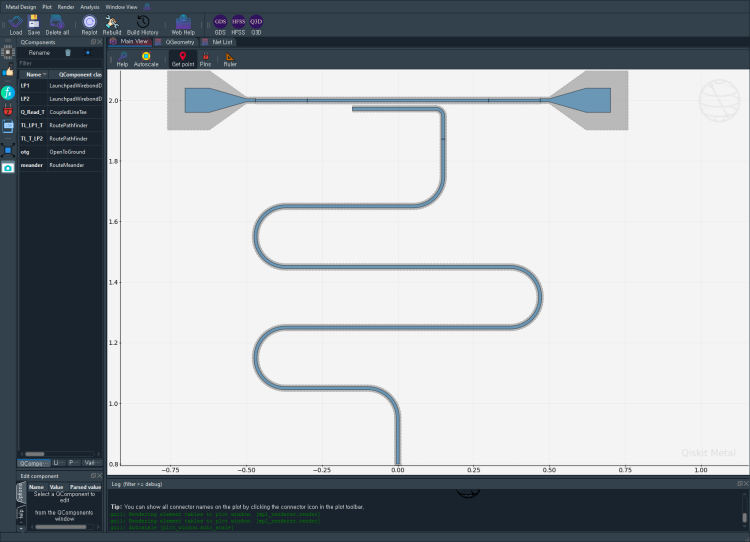

In [68]:
gui.autoscale()
gui.screenshot()

# Scattering Analysis

In [69]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
em1 = ScatteringImpedanceSim(design, "hfss")

In [70]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

# Here, pin LP1_in and LP2_in are converted into lumped ports,
#           each with an impedance of 50 Ohms. <br>
port_list = [('LP1', 'in', 50),
             ('LP2', 'in', 50)]
box_plus_buffer = True

In [71]:
em1.setup.name = "Sweep_DrivenModal_setup"
em1.setup.freq_ghz = 6.0 # Try to keep this at the center of the swept frequency range for 'fast' sweeps and at the largest frequency for interpolating sweep for the best results
em1.setup.max_delta_s = 0.005 # This is necessary to get good results if interpolating sweep is not working for you
em1.setup.max_passes = 18
em1.setup.min_passes = 2
em1.setup.basis_order = -1 # Mixed order
em1.setup

{'name': 'Sweep_DrivenModal_setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'freq_ghz': 6.0,
 'max_delta_s': 0.005,
 'max_passes': 18,
 'min_passes': 2,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': -1,
 'vars': {'Lj': '10 nH', 'Cj': '0 fF'},
 'sweep_setup': {'name': 'Sweep',
  'start_ghz': 2.0,
  'stop_ghz': 8.0,
  'count': 101,
  'step_ghz': None,
  'type': 'Fast',
  'save_fields': False}}

In [72]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

INFO 10:58AM [connect_project]: Connecting to Ansys Desktop API...
INFO 10:58AM [load_ansys_project]: 	Opened Ansys App
INFO 10:58AM [load_ansys_project]: 	Opened Ansys Desktop v2024.2.0
INFO 10:58AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Jaseung/Documents/Ansoft/
	Project:   Project24


INFO 10:58AM [connect_design]: 	Opened active design
	Design:    Design_hfss [Solution type: HFSS Modal Network]
INFO 10:58AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 10:58AM [connect]: 	Connected to project "Project24" and design "Design_hfss" 😀 



True

In [73]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.1
hfss.options['y_buffer_width_mm'] = 0.1

In [74]:
# clean the design if needed
hfss.clean_active_design()

In [78]:
# render the design
em1._render(selection=[],
                    solution_type='drivenmodal',
                    vars_to_initialize=em1.setup.vars, 
                    open_pins=open_terminations, 
                    port_list=port_list, 
                    box_plus_buffer = box_plus_buffer)

INFO 10:58AM [connect_design]: 	Opened active design
	Design:    Design_hfss [Solution type: HFSS Modal Network]
10:58AM 53s WARNING [activate_ansys_design]: The design_name=Design_hfss already exists, but it has solution_type==hfss modal network, which is different from the requested==drivenmodal. If you want a design with solution type==drivenmodal, please change the name requested for your design to one that does not exist. Alternatively, manually modify the solution_type for design Design_hfss from the Ansys GUI.


'Design_hfss'

In [79]:
#for accurate simulations, make sure the mesh is fine enough for the meander
hfss.modeler.mesh_length(
                'cpw_mesh',
                ['trace_meander'],
                MaxLength='0.02mm')

# Broad sweet to find the resonance

In [84]:
em1.setup.sweep_setup.start_ghz = 5.0
em1.setup.sweep_setup.stop_ghz = 8.0
em1.setup.sweep_setup.count = 10001
em1.setup.sweep_setup.type = "Fast"
em1._analyze() # This is necessary to keep the changes made to max_delta_s and min_passes

INFO 11:07AM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 11:07AM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 11:07AM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


In [85]:
hfss.plot_params(['S21'])
# make sure that you can see a dip in S21. If not, change the frequency sweep region or decrease the MaxLength of the mesh and retry.
# Or you can even try an interpolating sweep

(                       S21
 5.0000 -0.912918+0.408131j
 5.0003 -0.912908+0.408154j
 5.0006 -0.912897+0.408177j
 5.0009 -0.912887+0.408200j
 5.0012 -0.912877+0.408223j
 ...                    ...
 7.9988 -0.782511+0.622631j
 7.9991 -0.782495+0.622651j
 7.9994 -0.782479+0.622671j
 7.9997 -0.782464+0.622691j
 8.0000 -0.782448+0.622710j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

In [86]:
hfss.get_convergences() # Make sure that it converges

(             Solved Elements  Max Mag. Delta S
 Pass Number                                   
 1                      53263               NaN
 2                      66195          0.511050
 3                      76118          0.320440
 4                      87848          0.142180
 5                     111891          0.052795
 6                     132017          0.024154
 7                     165509          0.010612
 8                     214503          0.007391
 9                     260688          0.003788,
 None,
 "DesignVariation : Cj='0fF' Lj='10nH'\nSetup : Sweep_DrivenModal_setup\n\n==================\nNumber of Passes\nCompleted : 9\nMaximum   : 18\nMinimum   : 2\n==================\nCriterion : Max Mag. Delta S\nTarget    : 0.005\nCurrent   : 0.0037877\nTarget Consecutive Passes  : 1\nCurrent Consecutive Passes : 1\nConverged : Yes\n==================\nPass Number|Solved Elements|Max Mag. Delta S|\n          1|          53263|             N/A|\n          2|      

In [87]:
# extract the S21 parameters
freqs, Pcurves, Pparams = hfss.get_params(['S21'])
# find argmin 
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res # If the dip at f_res is not deep enough to be the minimum in the plot, try to eyeball its location and set it here. A better way would be to use scipy's find_peaks functionality

7175900000.0

# Narrow sweep around the resonance found above

In [24]:
em1.setup.sweep_setup.start_ghz = np.round(f_res/1e9,5)-0.05
em1.setup.sweep_setup.stop_ghz = np.round(f_res/1e9,5)+0.05
em1._analyze()

INFO 05:29PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 05:29PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 05:29PM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


In [25]:
hfss.plot_params(['S21'])

(                        S21
 6.55960 -0.848253+0.529582j
 6.55961 -0.848251+0.529584j
 6.55962 -0.848250+0.529586j
 6.55963 -0.848249+0.529588j
 6.55964 -0.848248+0.529590j
 ...                     ...
 6.65956 -0.851225+0.524683j
 6.65957 -0.851224+0.524685j
 6.65958 -0.851223+0.524687j
 6.65959 -0.851222+0.524689j
 6.65960 -0.851220+0.524691j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

In [26]:
freqs, Pcurves, Pparams = hfss.get_params(['S21'])

In [29]:
# find argmin
f_res = freqs[np.argmin(np.abs(Pparams.S21.values))]
f_res

6609440000.0

In [32]:
hfss

# Very-Narrow sweep around the resonance found above

In [33]:
em1.setup.sweep_setup.start_ghz = np.round(f_res/1e9,5)-0.005
em1.setup.sweep_setup.stop_ghz = np.round(f_res/1e9,5)+0.005
em1._analyze()

INFO 05:35PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 05:35PM [get_setup]: 	Opened setup `Sweep_DrivenModal_setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)
INFO 05:35PM [analyze]: Analyzing setup Sweep_DrivenModal_setup : Sweep


In [34]:
hfss.plot_params(['S21'])

(                         S21
 6.604440 -0.809002+0.584036j
 6.604441 -0.808993+0.584047j
 6.604442 -0.808984+0.584058j
 6.604443 -0.808975+0.584069j
 6.604444 -0.808966+0.584080j
 ...                      ...
 6.614436 -0.882191+0.464959j
 6.614437 -0.882185+0.464972j
 6.614438 -0.882180+0.464985j
 6.614439 -0.882174+0.464998j
 6.614440 -0.882168+0.465011j
 
 [10001 rows x 1 columns],
 <Figure size 1000x600 with 2 Axes>)

In [35]:
freqs, Pcurves, Pparams = hfss.get_params(['S21'])

In [36]:
from qiskit_metal.analyses.em.transmission_fitting import fit_transmission

In [37]:
fit_transmission(freqs,Pparams.S21.values) # This fits the transmission, plots the fit over the raw data, and returns only the parameters best fit parameters and plots

({'amplitude_complex': (-0.8090024019736138+0.5840359337862798j),
  'Qr': 10191.551962104091,
  'Qc': 10213.195012672883,
  'fr': 6609441122.818966,
  'phi0': 0.003995188650388879,
  'delay': -2.230987421979379e-09},
 [<Figure size 1280x960 with 3 Axes>,
  array([<Axes: xlabel='Freq (Hz)', ylabel='|S21|'>,
         <Axes: xlabel='Freq (Hz)', ylabel='arg(S21)'>,
         <Axes: xlabel='Re(S21)', ylabel='Im(S21)'>], dtype=object)])

In [38]:
# This fits the transmission, but does not generate the plot. Also, returns the fit parameters as a vector and the associated covariance matrix
fit_dict, _, fit_vec, fit_cov = fit_transmission(freqs,Pparams.S21.values, full_output=True, plot=False)

# To obtain the standard deviations from the covariance matrix, use the below
np.sqrt(np.diag(fit_cov))

array([2.66352062e-04, 1.46983157e-09, 1.34777775e-09, 5.94452695e-12,
       1.30498224e-09, 8.11342234e-04, 6.42795249e-15])

# Close connections

In [37]:
#from qiskit_metal import q13

In [39]:
em1.close()

In [40]:
hfss.disconnect_ansys()

In [24]:
#gui.main_window.close()
from qiskit_metal.qlibrary.kriss_components.jk_utils import (
    calculate_total_readout_res_length_between_qubit_and_feedline,
    calculate_coupledT_length
) 
calculate_coupledT_length(q_read)

0.38926990816987245

In [25]:
calculate_coupledT_length(q_read) + rt_meander.p.total_length

4.0892699081698725

In [41]:
#%% resonator fit
from qiskit_metal.analyses.em.transmission_fitting import fit_transmission

freqs, Pcurves, Pparams = hfss.get_params(['S21'])
fit_transmission(freqs,Pparams.S21.values) # This fits the transmission, plots the fit over the raw data, and returns only the parameters best fit parameters and plots


  Qr_init = 2. * fr_init / np.ptp(band_rough)

  return (2. * np.arctan(2. * Qr * (1. - (freq / fr))) - theta - phas +



ValueError: Each lower bound must be strictly less than each upper bound.

In [42]:
Pparams

,S21
4.0000,-0.943992+0.329921j
4.0004,-0.943981+0.329953j
4.0008,-0.943970+0.329985j
4.0012,-0.943959+0.330017j
4.0016,-0.943948+0.330048j
...,...
7.9984,-0.782583+0.622494j
7.9988,-0.782562+0.622521j
7.9992,-0.782541+0.622547j
7.9996,-0.782520+0.622573j


In [43]:
Pcurves

[array([-0.94399225+0.32992142j, -0.94398115+0.32995316j,
        -0.94397005+0.32998491j, ..., -0.78254129+0.62254692j,
        -0.78252027+0.62257334j, -0.78249925+0.62259976j])]